In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    name: str
    operation: str
    values: List[int]
    result: str

In [3]:
def operation_node(state: AgentState) -> AgentState:
    main=''
    if state["operation"] == "+":
        main = str(sum(state["values"]))
    elif state["operation"] == "*":
        result = 1
        for value in state["values"]:
            result *= value
        main = str(result)
    else:
        main = "Unsupported operation"
    state["result"] = main

    return state

In [4]:
graph = StateGraph(AgentState)
graph.add_node("operation_Time", operation_node)
graph.set_entry_point("operation_Time")
graph.set_finish_point("operation_Time")

In [5]:
test = graph.compile()

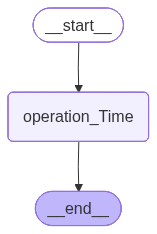

In [6]:
test

In [7]:
results = test.invoke({"values": [1, 2, 3], "name": "Alice", "result": "", "operation": "+"})
print(results)

{'name': 'Alice', 'operation': '+', 'values': [1, 2, 3], 'result': '6'}


In [ ]:
results = test.invoke({"values": [1, 2, 8], "name": "Alice", "result": "", "operation": "*"})
print(results)

{'name': 'Alice', 'operation': '*', 'values': [1, 2, 8], 'result': '16'}


: 